# Mean - Variance Optimization

$$
\min_{\omega} \sigma_{PF}^2 = \omega^T \Sigma \omega \\
s.t. \mu_{PF} = \omega^T \mu  \\
|| \omega ||_1 = 1
$$


In [20]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
from numpy.random import random, uniform, dirichlet, choice
from numpy.linalg import inv

from scipy.optimize import minimize

import pandas_datareader.data as web
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [22]:
sns.set_style('whitegrid')
np.random.seed(42)

In [23]:
cmap = sns.diverging_palette(10, 240, n=9, as_cmap=True)

In [24]:
with pd.HDFStore( os.path.join("..", "..", "data", "assets.h5")) as store :
    data = store["prices/chile"]

# Compute inputs

In [25]:
start = 2015
end = 2025

In [26]:
returns = data.loc[f'{start}' : f'{end}'].pct_change().dropna(how = "all") # removes if all elements in row are Nan
print("all data columns", len(returns.columns))

all_columns = set(returns.columns)

returns = returns.dropna(axis = 1)
print("filtered data", len(returns.columns))
print("Tickers left out:", all_columns - set(returns.columns))

print("")
returns.info()

all data columns 120
filtered data 102
Tickers left out: {'OXIQUIM.SN', 'ITAUCL.SN', 'BICE.SN', 'BINT.SN', 'CTC.SN', 'NTGCLGAS.SN', 'TRICOT.SN', 'SMU.SN', 'MANQUEHUE.SN', 'CUPRUM.SN', 'NUAM.SN', 'ENELCHILE.SN', 'LIPIGAS.SN', 'CGET.SN', 'ABC.SN', 'MALLPLAZA.SN', 'CENCOMALLS.SN', 'SALMOCAM.SN'}

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2864 entries, 2015-01-02 to 2025-12-29
Columns: 102 entries, NAVARINO.SN to PEHUENCHE.SN
dtypes: float64(102)
memory usage: 2.3 MB


In [27]:
stocks = returns.columns
n_obs, n_assets = returns.shape
n_assets, n_obs

(102, 2864)

In [28]:
NUM_PF = 20_000

x0 = uniform(0, 1, n_assets)
x0 /= np.sum(np.abs(x0))

## Annualization Factor

In [29]:
periods_per_year = round(returns.resample('A').size().mean())
periods_per_year

260

In [30]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

The precision matrix is the inverse of the covariance matrix:

In [31]:
precision_matrix = pd.DataFrame(inv(cov_matrix), index=stocks, columns=stocks)

In [32]:
treasury_10yr_daily = (web.DataReader('DGS10', 'fred', start, end)
                         .resample('M')
                         .last()
                         .div(periods_per_year)
                         .div(100)
                         .squeeze())

In [33]:
rf_rate = treasury_10yr_daily.mean()
rf_rate

np.float64(9.508653846153845e-05)

## Simulate Random Portfolios

In [34]:
alpha = np.full(shape=n_assets, fill_value=.05)
weights = dirichlet(alpha=alpha, size=NUM_PF)
weights.shape, mean_returns.shape

((20000, 102), (102,))

In [35]:
def simulate_portfolios(mean_ret, cov, rf_rate=rf_rate, short=False):
    alpha = np.full(shape=n_assets, fill_value=.05)
    weights = dirichlet(alpha=alpha, size=NUM_PF)
    if short:
        weights *= choice([-1, 1], size=weights.shape)

    returns = weights @ mean_ret.values + 1
    returns = returns ** periods_per_year - 1
    std = np.sqrt(np.diag(weights @ cov.values @ weights.T))
    std *= np.sqrt(periods_per_year)
    sharpe = (returns - rf_rate) / std
    return pd.DataFrame({'Annualized Standard Deviation': std,
                         'Annualized Returns': returns,
                         'Sharpe Ratio': sharpe}), weights

In [36]:
simul_perf, simul_wt = simulate_portfolios(mean_returns, cov_matrix, short=False)

In [37]:
df = pd.DataFrame(simul_wt)
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,100,101
count,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,...,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04
mean,1.033003e-02,1.003369e-02,9.690748e-03,1.001789e-02,8.937160e-03,9.793105e-03,9.844433e-03,1.012793e-02,1.014058e-02,1.066820e-02,...,1.028635e-02,9.693050e-03,1.025155e-02,9.816749e-03,9.821891e-03,9.997758e-03,9.925423e-03,9.534335e-03,9.838334e-03,9.913593e-03
std,4.166952e-02,4.273321e-02,3.954834e-02,3.990590e-02,3.659227e-02,3.914348e-02,4.108815e-02,4.190135e-02,4.081060e-02,4.246749e-02,...,4.235312e-02,3.909387e-02,4.144632e-02,4.108540e-02,3.976628e-02,4.048784e-02,4.132154e-02,3.853141e-02,3.922905e-02,3.971902e-02
min,2.576440e-93,3.090929e-83,3.885959e-78,6.018514e-87,1.100587e-85,5.335232e-92,3.765426e-86,6.844247e-101,2.321919e-113,2.093904e-80,...,2.020752e-83,6.226820e-94,2.845407e-93,1.093865e-92,2.464437e-93,5.201277e-109,1.344882e-97,8.920859e-76,1.310329e-84,5.081471e-93
25%,1.168076e-13,9.663883e-14,7.155462e-14,1.441819e-13,1.063303e-13,1.109562e-13,8.519565e-14,1.750466e-13,1.360644e-13,1.331298e-13,...,7.372347e-14,8.126767e-14,1.075933e-13,1.069426e-13,1.282102e-13,1.529805e-13,7.579329e-14,1.737382e-13,1.367928e-13,9.576028e-14
50%,1.470980e-07,1.310366e-07,1.115824e-07,1.389082e-07,1.150559e-07,1.330086e-07,1.053591e-07,1.604962e-07,1.456769e-07,1.343911e-07,...,1.023781e-07,1.149808e-07,1.210645e-07,1.065460e-07,1.116183e-07,1.643366e-07,1.059086e-07,1.124248e-07,1.218042e-07,1.283019e-07
75%,4.436196e-04,3.932380e-04,3.880702e-04,4.347856e-04,3.623707e-04,3.963366e-04,3.740037e-04,4.696088e-04,4.370404e-04,4.588652e-04,...,3.652259e-04,3.966650e-04,4.268847e-04,3.847163e-04,4.292624e-04,4.552096e-04,3.405292e-04,3.996497e-04,4.200760e-04,4.283370e-04
max,7.141748e-01,6.737745e-01,7.422228e-01,6.562350e-01,5.903897e-01,7.140268e-01,6.513407e-01,7.312909e-01,7.375381e-01,7.013504e-01,...,6.623204e-01,5.902003e-01,7.645228e-01,6.945819e-01,6.374146e-01,6.716300e-01,7.995484e-01,8.587717e-01,6.248419e-01,6.914317e-01


Max Sharpe: 10.26%, 21.04%


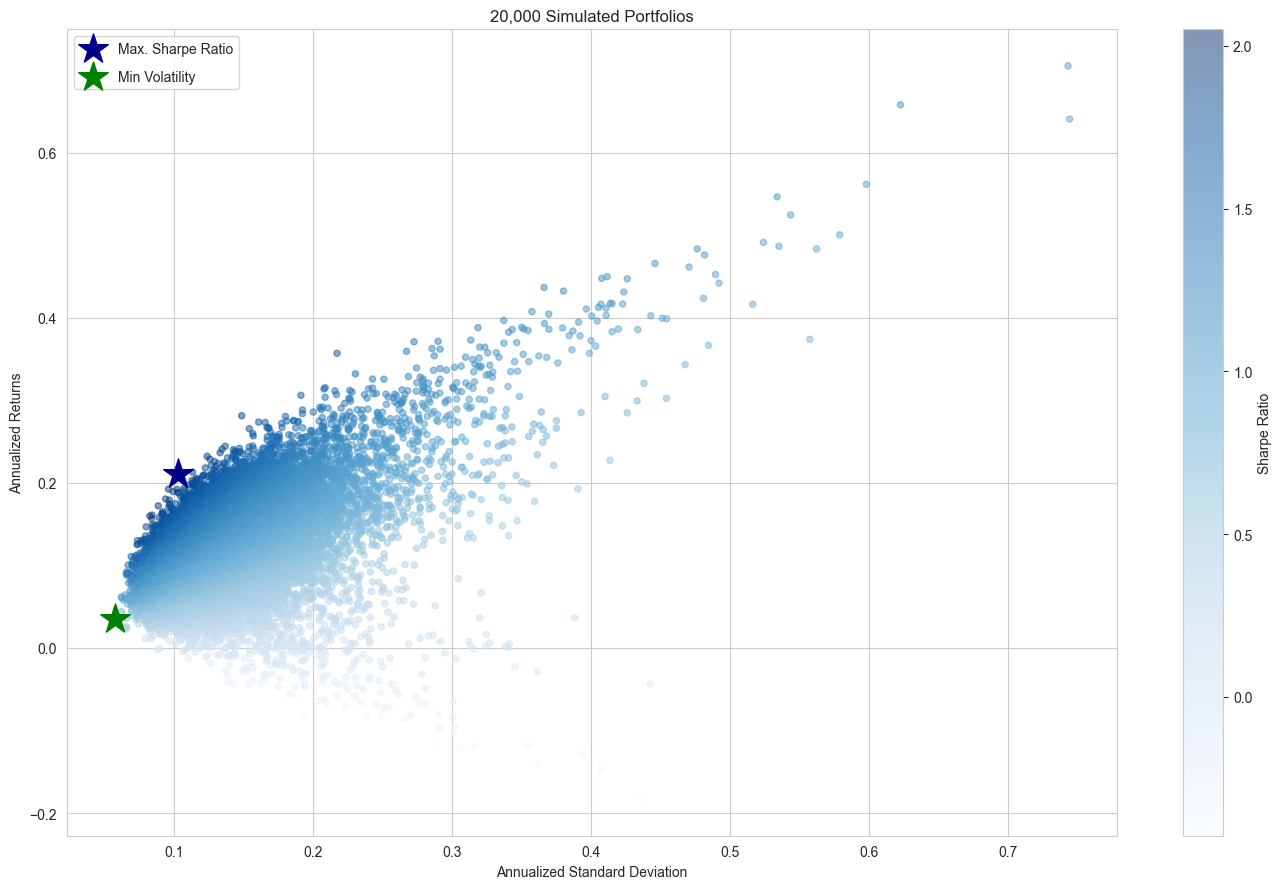

In [38]:
ax = simul_perf.plot.scatter(x=0, y=1, c=2, cmap='Blues',
                             alpha=0.5, figsize=(14, 9), colorbar=True,
                             title=f'{NUM_PF:,d} Simulated Portfolios')

max_sharpe_idx = simul_perf.iloc[:, 2].idxmax()
sd, r = simul_perf.iloc[max_sharpe_idx, :2].values
print(f'Max Sharpe: {sd:.2%}, {r:.2%}')
ax.scatter(sd, r, marker='*', color='darkblue', s=500, label='Max. Sharpe Ratio')

min_vol_idx = simul_perf.iloc[:, 0].idxmin()
sd, r = simul_perf.iloc[min_vol_idx, :2].values
ax.scatter(sd, r, marker='*', color='green', s=500, label='Min Volatility')
plt.legend(labelspacing=1, loc='upper left')
plt.tight_layout()

## Compute Annualize PF Performance

Now we'll set up the quadratic optimization problem to solve for the minimum standard deviation for a given return or the maximum SR.

To this end, define the functions that measure the key metrics:

In [39]:
def portfolio_std(wt, rt=None, cov=None):
    """Annualized PF standard deviation"""
    return np.sqrt(wt @ cov @ wt * periods_per_year)

def portfolio_returns(wt, rt=None, cov=None):
    """Annualized PF returns"""
    return (wt @ rt + 1) ** periods_per_year - 1

def portfolio_performance(wt, rt, cov):
    """Annualized PF returns & standard deviation"""
    r = portfolio_returns(wt, rt=rt)
    sd = portfolio_std(wt, cov=cov)
    return r, sd

## Max Sharpe PF

Define a target function that represents the negative SR for scipy's minimize function to optimize, given the constraints that the weights are bounded by [-1, 1], if short trading is permitted, and [0, 1] otherwise, and sum to one in absolute terms.

In [40]:
def neg_sharpe_ratio(weights, mean_ret, cov):
    r, sd = portfolio_performance(weights, mean_ret, cov)
    return -(r - rf_rate) / sd

In [41]:
weight_constraint = {'type': 'eq', 
                     'fun': lambda x: np.sum(np.abs(x))-1}

In [42]:
def max_sharpe_ratio(mean_ret, cov, short=False):
    return minimize(fun=neg_sharpe_ratio,
                    x0=x0,
                    args=(mean_ret, cov),
                    method='SLSQP',
                    bounds=((-1 if short else 0, 1),) * n_assets,
                    constraints=weight_constraint,
                    options={'tol':1e-10, 'maxiter':1e4})

## Compute efficient frontier

In [43]:
def min_vol_target(mean_ret, cov, target, short=False):

    def ret_(wt):
        return portfolio_returns(wt, mean_ret)

    constraints = [{'type': 'eq',
                    'fun': lambda x: ret_(x) - target},
                   weight_constraint]

    bounds = ((-1 if short else 0, 1),) * n_assets
    return minimize(portfolio_std,
                    x0=x0,
                    args=(mean_ret, cov),
                    method='SLSQP',
                    bounds=bounds,
                    constraints=constraints,
                    options={'tol': 1e-10, 'maxiter': 1e4})

The mean-variance frontier relies on in-sample, backward-looking optimization. In practice, portfolio optimization requires forward-looking input. Unfortunately, expected returns are notoriously difficult to estimate accurately.

The covariance matrix can be estimated somewhat more reliably, which has given rise to several alternative approaches. However, covariance matrices with correlated assets pose computational challenges since the optimization problem requires inverting the matrix. The high condition number induces numerical instability, which in turn gives rise to Markovitz curse: the more diversification is required (by correlated investment opportunities), the more unreliable the weights produced by the algorithm.

## Min Volatility Portfolio

In [44]:
def min_vol(mean_ret, cov, short=False):
    bounds = ((-1 if short else 0, 1),) * n_assets

    return minimize(fun=portfolio_std,
                    x0=x0,
                    args=(mean_ret, cov),
                    method='SLSQP',
                    bounds=bounds,
                    constraints=weight_constraint,
                    options={'tol': 1e-10, 'maxiter': 1e4})

In [45]:
def efficient_frontier(mean_ret, cov, ret_range, short=False):
    return [min_vol_target(mean_ret, cov, ret) for ret in ret_range]

## Run Calculation

### Get random PF

In [46]:
simul_perf, simul_wt = simulate_portfolios(mean_returns, cov_matrix, short=False)

In [47]:
print(simul_perf.describe())

       Annualized Standard Deviation  Annualized Returns  Sharpe Ratio
count                   20000.000000        20000.000000  20000.000000
mean                        0.142044            0.124867      0.901738
std                         0.046062            0.055175      0.319983
min                         0.057301           -0.153714     -0.456054
25%                         0.113042            0.091791      0.710252
50%                         0.133118            0.121578      0.914782
75%                         0.158799            0.153427      1.114096
max                         0.818386            0.777113      2.089055


In [48]:
simul_max_sharpe = simul_perf.iloc[:, 2].idxmax()
simul_perf.iloc[simul_max_sharpe]

Annualized Standard Deviation    0.105552
Annualized Returns               0.220598
Sharpe Ratio                     2.089055
Name: 9573, dtype: float64

## Get Max Sharpe PF

In [49]:
max_sharpe_pf = max_sharpe_ratio(mean_returns, cov_matrix, short=False)
max_sharpe_perf = portfolio_performance(max_sharpe_pf.x, mean_returns, cov_matrix)

In [50]:
r, sd = max_sharpe_perf
pd.Series({'ret': r, 'sd': sd, 'sr': (r-rf_rate)/sd})

ret    0.186728
sd     0.048449
sr     3.852181
dtype: float64

### Get Min Vol PF

In [51]:
min_vol_pf = min_vol(mean_returns, cov_matrix, short=False)
min_vol_perf = portfolio_performance(min_vol_pf.x, mean_returns, cov_matrix)

### Get Efficent PFs

In [52]:
ret_range = np.linspace(simul_perf.iloc[:, 1].min(), simul_perf.iloc[:, 1].max(), 50)
eff_pf = efficient_frontier(mean_returns, cov_matrix, ret_range, short=True)
eff_pf = pd.Series(dict(zip([p['fun'] for p in eff_pf], ret_range)))

## Plot Result

The simulation yields a subset of the feasible portfolios, and the efficient frontier identifies the optimal in-sample return-risk combinations that were achievable given historic data.

The below figure shows the result including the minimum variance portfolio and the portfolio that maximizes the SR and several portfolios produce by alternative optimization strategies. The efficient frontier

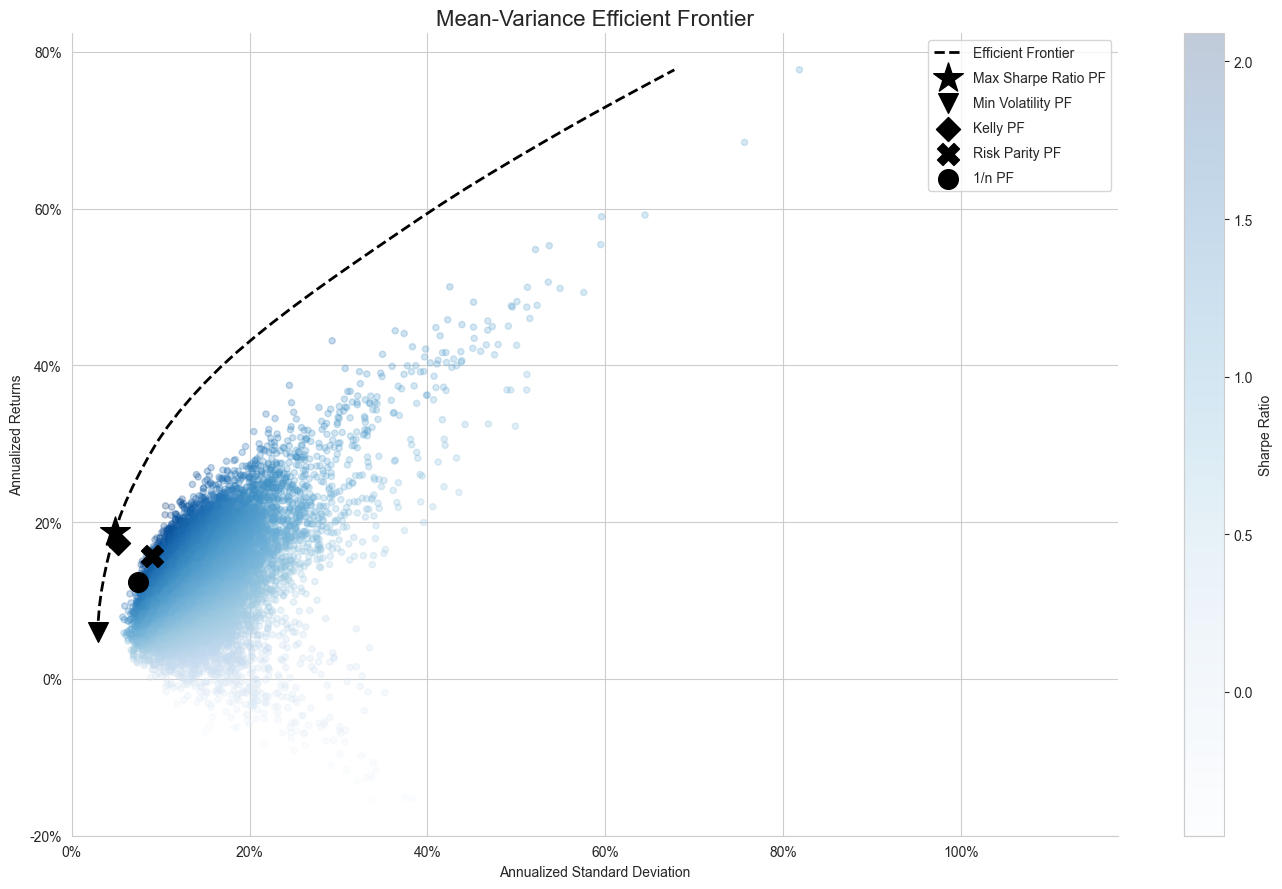

In [54]:
fig, ax = plt.subplots()
simul_perf.plot.scatter(x=0, y=1, c=2, ax=ax, cmap='Blues',alpha=0.25, 
                        figsize=(14, 9), colorbar=True)

eff_pf[eff_pf.index.min():].plot(linestyle='--', lw=2, ax=ax, c='k',
                                 label='Efficient Frontier')

r, sd = max_sharpe_perf
ax.scatter(sd, r, marker='*', color='k', s=500, label='Max Sharpe Ratio PF')

r, sd = min_vol_perf
ax.scatter(sd, r, marker='v', color='k', s=200, label='Min Volatility PF')

kelly_wt = precision_matrix.dot(mean_returns).clip(lower=0).values
kelly_wt /= np.sum(np.abs(kelly_wt))
r, sd = portfolio_performance(kelly_wt, mean_returns, cov_matrix)
ax.scatter(sd, r, marker='D', color='k', s=150, label='Kelly PF')

std = returns.std()
std /= std.sum()
r, sd = portfolio_performance(std, mean_returns, cov_matrix)
ax.scatter(sd, r, marker='X', color='k', s=250, label='Risk Parity PF')

r, sd = portfolio_performance(np.full(n_assets, 1/n_assets), mean_returns, cov_matrix)
ax.scatter(sd, r, marker='o', color='k', s=200, label='1/n PF')


ax.legend(labelspacing=0.8)
ax.set_xlim(0, eff_pf.max()+.4)
ax.set_title('Mean-Variance Efficient Frontier', fontsize=16)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
fig.tight_layout();